In [1]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(42)

## Cut-DeepONet - (with exact solution dataset)

-, Step 1: Load data - and Piecewise Cutting \
-, Step 2: Training \
-, Step 3: Cutting Net Loading \
-, Step 4: Test performance & Tracking

#### Step 1: Load data (makes the avoid discontinuity output have the same length)

In [2]:
def I_stim(t, a_stim, d_stim, t_stim):
    return sum(
        a_stim_ * (t >= t_stim_) * (t <= t_stim_ + d_stim_) 
        for t_stim_, d_stim_, a_stim_ in zip(t_stim, d_stim, a_stim)
    )

T, dt = 400, 0.005                 # in ms
N = 300                            # number of samples
Nt = int(T / dt) + 1              # number of time steps
df = np.load(f"data/pr_n_data_{N}_T_400_dt_0.005_d_stim_0.88.npz")
sharp_jump_data = np.load(f"data/pr_n_data_{N}_one_sharp.npz")
t_stim, a_stim, d_stim = df['t_stim'], df['a_stim'], df['d_stim']

input_data = np.concatenate([a_stim, d_stim, t_stim], axis=1)  # (N, 3)
output_data = df["v"].squeeze(-1)
sharp_jump_all = sharp_jump_data['sharp_jump'][:, :-1]  # (300, 2)
t = np.arange(0, T + dt, dt).reshape(-1, 1)

train_idx = df['train_idx']
val_idx = df['val_idx']
test_idx = df['test_idx']

# plotting_impluse_action_potential(t, output_data[0], I_stim(t, a_stim[0], d_stim[0], t_stim[0]), T=T)
print(f" input_data shape: {input_data.shape}, output_data shape: {output_data.shape}, t shape: {t.shape}, sharp_jump shape: {sharp_jump_all.shape}")

 input_data shape: (300, 3), output_data shape: (300, 80001), t shape: (80001, 1), sharp_jump shape: (300, 2)


#### Lift the dimension of coordinate [T] -> [T, H(T)]

In [3]:
# Lifting at the discontinuity locations - check the x sample at the left or right of the discontinuity location at time step t_idx
def H(coorp_np, discon_coords):
    discon_1 = discon_coords[:, 0].astype(np.int64)
    discon_2 = discon_coords[:, 1].astype(np.int64)
    return np.where(coorp_np < coorp_np[discon_1], 0, np.where(coorp_np <= coorp_np[discon_2], 1, 2))

N, Nt = input_data.shape[0], t.shape[0]
t_coorp = np.broadcast_to(t[None, :, :], (N, Nt, 1))

lifted_coords_np = []
for idx in range(N):
    sharp_jump_coorp = np.tile(sharp_jump_all[idx, :2], (Nt, 1))  # (Nt, 2)
    Hx = H(t_coorp[idx], sharp_jump_coorp)  # (Nt,)
    lifted_coords_np.append(np.concatenate([t_coorp[idx], Hx], axis=1))  # (Nt, 2)

lifted_coords_np = np.array(lifted_coords_np)  # (N, Nt, 2)
print("Lifted coordinates shape:", lifted_coords_np.shape)  # (N, Nt, 2) [t, H(t)]

Lifted coordinates shape: (300, 80001, 2)


#### Step 2: Training Cut-DeepONet

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# 2) Define Cut-DeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=2, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, lifted_trunk_input):
        # branch_input: (B, Nx), lifted_trunk_input: (B, P, 2)
        b = self.branch(branch_input)      # (B, latent)
        # Trunk with lifted domain input
        t = self.trunk(lifted_trunk_input)     # (B, P, latent)
        y = torch.einsum('bl,bpl->bp', b, t) + self.bias  # (B, P)
        return y

model = DeepONet(branch_in=3, latent_dim=128, hidden_dim=256, depth=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 500
batch_size = 16 # Have to use batch_size is 1, because each case u_0, we have different location of output sampling. Thus the coords_np have location different for each case [N, Nt*reduced_Nx, 2]
points_per_step = 2000  # sampled (x,t) points per batch
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_idx), batch_size):
        # Input and Output for the current batch
        batched_idx = train_idx[start:start + batch_size] 
        batched_input = torch.tensor(input_data[batched_idx], dtype=torch.float32, device=device)   # (B, Nx)
        batched_output = torch.tensor(output_data[batched_idx], dtype=torch.float32, device=device) # (B, Nt, reduced-Nx)
        batched_x = torch.tensor(lifted_coords_np[batched_idx], dtype=torch.float32, device=device) # (B, Nt, reduced-Nx) - different for each case because of different location of output sampling

        # Randomly sample points in the t domain for training
        point_idx = rng.integers(0, Nt, points_per_step)
        sharp_jump_batch_list = sharp_jump_all[batched_idx].reshape(-1).tolist() # add the sharp jump locations to the training points, because these regions is small and might not be picked
        point_idx = np.concatenate([point_idx, sharp_jump_batch_list], axis=0)

        # Trunk input and target output for the sampled points
        lifted_trunk_input = torch.tensor(batched_x[:, point_idx], dtype=torch.float32, device=device)  # (P, 3)
        output_target = torch.tensor(batched_output[:, point_idx], dtype=torch.float32, device=device)  # (P, B)

        optimizer.zero_grad()
        output_pred = model(batched_input, lifted_trunk_input)
        loss = loss_fn(output_pred, output_target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_losses.append(epoch_loss / max(n_batches, 1))

    # quick validation (random sampled points)
    model.eval()
    with torch.no_grad():
        batched_val = val_idx if len(val_idx) <= 32 else rng.choice(val_idx, size=32, replace=False)
        batched_input_val = torch.tensor(input_data[batched_val], dtype=torch.float32, device=device)
        batched_output_val = torch.tensor(output_data[batched_val], dtype=torch.float32, device=device)
        batched_x_val = torch.tensor(lifted_coords_np[batched_val], dtype=torch.float32, device=device)

        # Randomly sample points in the t domain for training
        point_idx = rng.integers(0, Nt, size=points_per_step)

        lifted_trunk_input_val = torch.tensor(batched_x_val[:, point_idx], dtype=torch.float32, device=device)
        output_val_target = torch.tensor(batched_output_val[:, point_idx], dtype=torch.float32, device=device)

        output_val_pred = model(batched_input_val, lifted_trunk_input_val)
        val_loss = loss_fn(output_val_pred, output_val_target).item()
        val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_losses[-1]:.6e} | val_loss={val_losses[-1]:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/cut_deeponet_checkpoint.pt")
print("Saved: cut_deeponet_checkpoint.pt")

Epoch    1/500 | train_loss=2.691852e+03 | val_loss=2.570625e+03
Epoch   20/500 | train_loss=4.953210e+02 | val_loss=5.139169e+02
Epoch   40/500 | train_loss=4.743627e+02 | val_loss=3.931239e+02
Epoch   60/500 | train_loss=3.738052e+02 | val_loss=3.793272e+02
Epoch   80/500 | train_loss=1.829293e+02 | val_loss=1.751384e+02
Epoch  100/500 | train_loss=1.205010e+02 | val_loss=1.820415e+02
Epoch  120/500 | train_loss=7.661138e+01 | val_loss=9.992891e+01
Epoch  140/500 | train_loss=1.244840e+02 | val_loss=7.854745e+01
Epoch  160/500 | train_loss=6.739832e+01 | val_loss=6.181732e+01
Epoch  180/500 | train_loss=6.383955e+01 | val_loss=5.886781e+01
Epoch  200/500 | train_loss=5.500853e+01 | val_loss=5.104255e+01
Epoch  220/500 | train_loss=5.063312e+01 | val_loss=4.581090e+01
Epoch  240/500 | train_loss=5.088822e+01 | val_loss=4.810723e+01
Epoch  260/500 | train_loss=4.384904e+01 | val_loss=5.151659e+01
Epoch  280/500 | train_loss=3.536464e+01 | val_loss=3.250983e+01
Epoch  300/500 | train_lo

#### Step 3: Cutting Net Loading

In [45]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[64, 64, 64]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Rebuild and load model weights
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

cutting_net = MLP(input_data.shape[1], sharp_jump_all.shape[1]).to(device)
cutting_net.load_state_dict(checkpoint["model_state_dict"])
cutting_net.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

#### Step 4: Test performance & Tracking

In [46]:
def predict_full_field(model, t, sample_input, Nt, chunk=20000):
    sample_input = torch.tensor(sample_input[None, :], dtype=torch.float32, device=device)  # (1, Nx)

    pred_sharp_jump = cutting_net(sample_input).detach().numpy()  # (1, Nt)
    sharp_jump_coorp = np.tile(pred_sharp_jump[:2], (Nt, 1))  # (Nt, 2)
    Hx = H(t, sharp_jump_coorp)  # (Nt,)
    pred_lifted_coords_np = np.concatenate([t, Hx], axis=1)  # (Nt, 2)

    preds = []
    with torch.no_grad():
        for i in range(0, pred_lifted_coords_np.shape[0], chunk):
            chunk_lifted_coords = torch.tensor(pred_lifted_coords_np[None, i:i+chunk], dtype=torch.float32, device=device)
            p = model(sample_input, chunk_lifted_coords).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt), pred_sharp_jump

def error_analysis_one_sample(pred, true, t, sharp_jump, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the sharp jump
    left_bound = np.maximum(sharp_jump[0] - window_size, 0)
    right_bound = np.minimum(t.shape[0], sharp_jump[1] + window_size + 1)
    l1_loss_near_sharp = np.mean(abs_err[left_bound:right_bound]) 

    return l1_loss, l1_loss_near_sharp, left_bound, right_bound

def error_analysis_dataset_test(model, input_data_test, output_data_test, t, sharp_jump_all, window_size=5):
    l1_loss_all, l1_loss_near_discon_all = [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field, _ = predict_full_field(model, t, input_data_test[sample_id], t.shape[0], chunk=20000)
        l1_loss, l1_loss_near_discon, _, _ = error_analysis_one_sample(pred_field, output_data_test[sample_id], t, sharp_jump_all[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, t, sharp_jump_all, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    lifted_coords_test = lifted_coords_np[test_idx]

    pred_field, _ = predict_full_field(model, t, input_data_test[sample_id], t.shape[0], chunk=20000)
    sample_global_idx = test_idx[sample_id] if "test_idx" in globals() else sample_id
    true_field = output_data_test[sample_id].reshape(-1)

    # _, _, left_bound, right_bound = error_analysis_one_sample(pred_field, true_field, t, sharp_jump_all[sample_id], window_size=int(0.05 * Nt))  # 5% of total points on each side of the discontinuity
    I_stim_sample = I_stim(t, [input_data_test[sample_id, 0]], [input_data_test[sample_id, 1]], [input_data_test[sample_id, 2]]).squeeze()

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
    axes[0].plot(t, I_stim_sample, color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, pred_field, color="red", label="Pred")
    axes[1].plot(t, true_field, color="blue", linestyle="--", label="True")
    # axes[1].axvline(t[left_bound], color="green", linestyle=":", label="Discontinuity region")
    # axes[1].axvline(t[right_bound], color="green", linestyle=":")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(t[:8500], pred_field[:8500], color="red", label="Pred")
    axes[2].plot(t[:8500], true_field[:8500], color="blue", linestyle="--", label="True")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("u")
    axes[2].grid(True)
    axes[2].legend()

    axes[3].plot(train_losses, label="Train")
    axes[3].plot(val_losses, label="Val")
    axes[3].set_yscale("log")
    axes[3].set_xlabel("Epoch")
    axes[3].set_title("Training Curve")
    axes[3].legend()
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

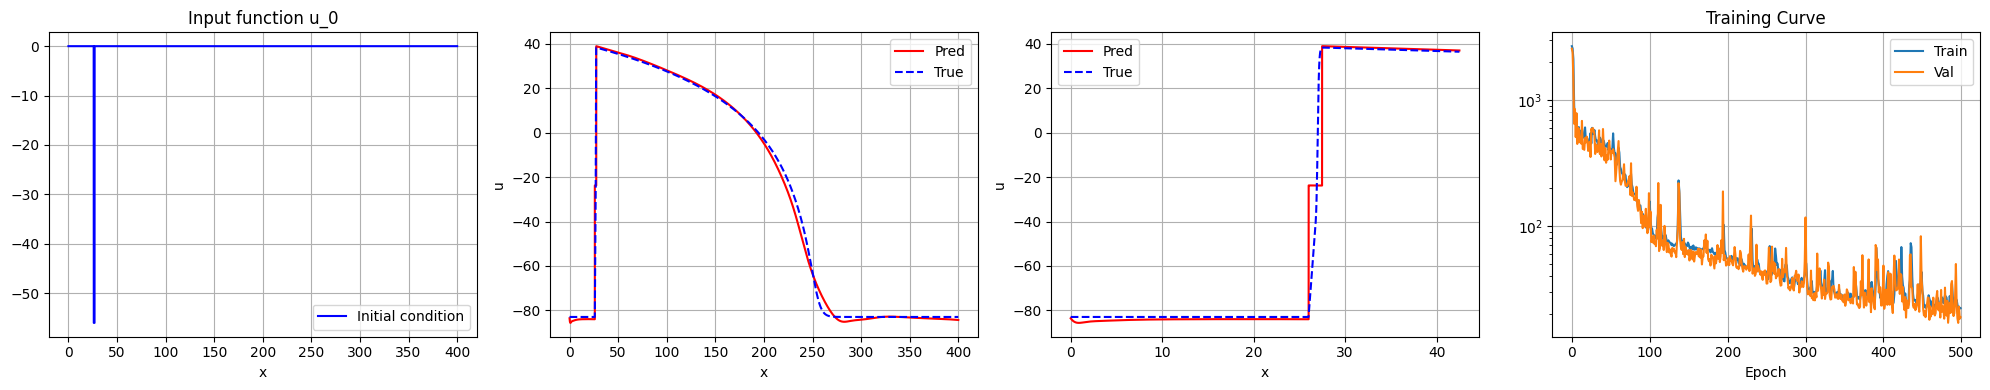

Total parameters: 330,753, trainable parameters: 330,753
L1 Loss (all points): 2.032, std: 0.830
L1 Loss (near discontinuity): 2.050, std: 0.588


In [48]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

input_data_test, output_data_test, sharp_jump_test = input_data[test_idx], output_data[test_idx], sharp_jump_all[test_idx]

l1_loss_all, l1_loss_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, t, sharp_jump_test, window_size=int(0.05 * Nt))
show_results(model, checkpoint, input_data_test, output_data_test, t, sharp_jump_test, sample_id=2)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")